# 05 — Global Comparison & Conclusions
## Universal Sequence Lab · Assignment 3

This notebook consolidates all results across the three modules and draws 
cross-cutting conclusions about **sequential architectures for DL tasks**.

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11})
print('Ready ✓')

Ready ✓


## 1. Results Summary Tables


In [2]:
# ─── Fill these with your actual results after running notebooks 02–04 ───

module_a = pd.DataFrame({
    'Model':      ['VanillaRNN', 'BiLSTM', 'BiGRU', 'Transformer'],
    'Test Acc':   [0.782, 0.884, 0.887, 0.901],
    'Test Loss':  [0.491, 0.301, 0.295, 0.268],
    'Params (K)': [4_800, 7_200, 5_900, 9_100],
}).set_index('Model')

module_b = pd.DataFrame({
    'Model':      ['Naive Baseline', 'LSTM', 'GRU', 'Transformer'],
    'RMSE':       [0.612, 0.381, 0.374, 0.351],
    'MAE':        [0.481, 0.282, 0.277, 0.254],
    'Params (K)': [0, 6_800, 5_200, 3_900],
}).set_index('Model')

module_c = pd.DataFrame({
    'Model':      ['Seq2Seq + Bahdanau Attention'],
    'BLEU':       [24.7],
    'Params (K)': [28_000],
}).set_index('Model')

print('Module A — NLP Sentiment Classification')
print(module_a.to_string())
print()
print('Module B — Time Series Forecasting')
print(module_b.to_string())
print()
print('Module C — EN→DE Translation')
print(module_c.to_string())

Module A — NLP Sentiment Classification
             Test Acc  Test Loss  Params (K)
Model                                       
VanillaRNN      0.782      0.491        4800
BiLSTM          0.884      0.301        7200
BiGRU           0.887      0.295        5900
Transformer     0.901      0.268        9100

Module B — Time Series Forecasting
                 RMSE    MAE  Params (K)
Model                                   
Naive Baseline  0.612  0.481           0
LSTM            0.381  0.282        6800
GRU             0.374  0.277        5200
Transformer     0.351  0.254        3900

Module C — EN→DE Translation
                              BLEU  Params (K)
Model                                         
Seq2Seq + Bahdanau Attention  24.7       28000


## 2. Global Comparison Dashboard


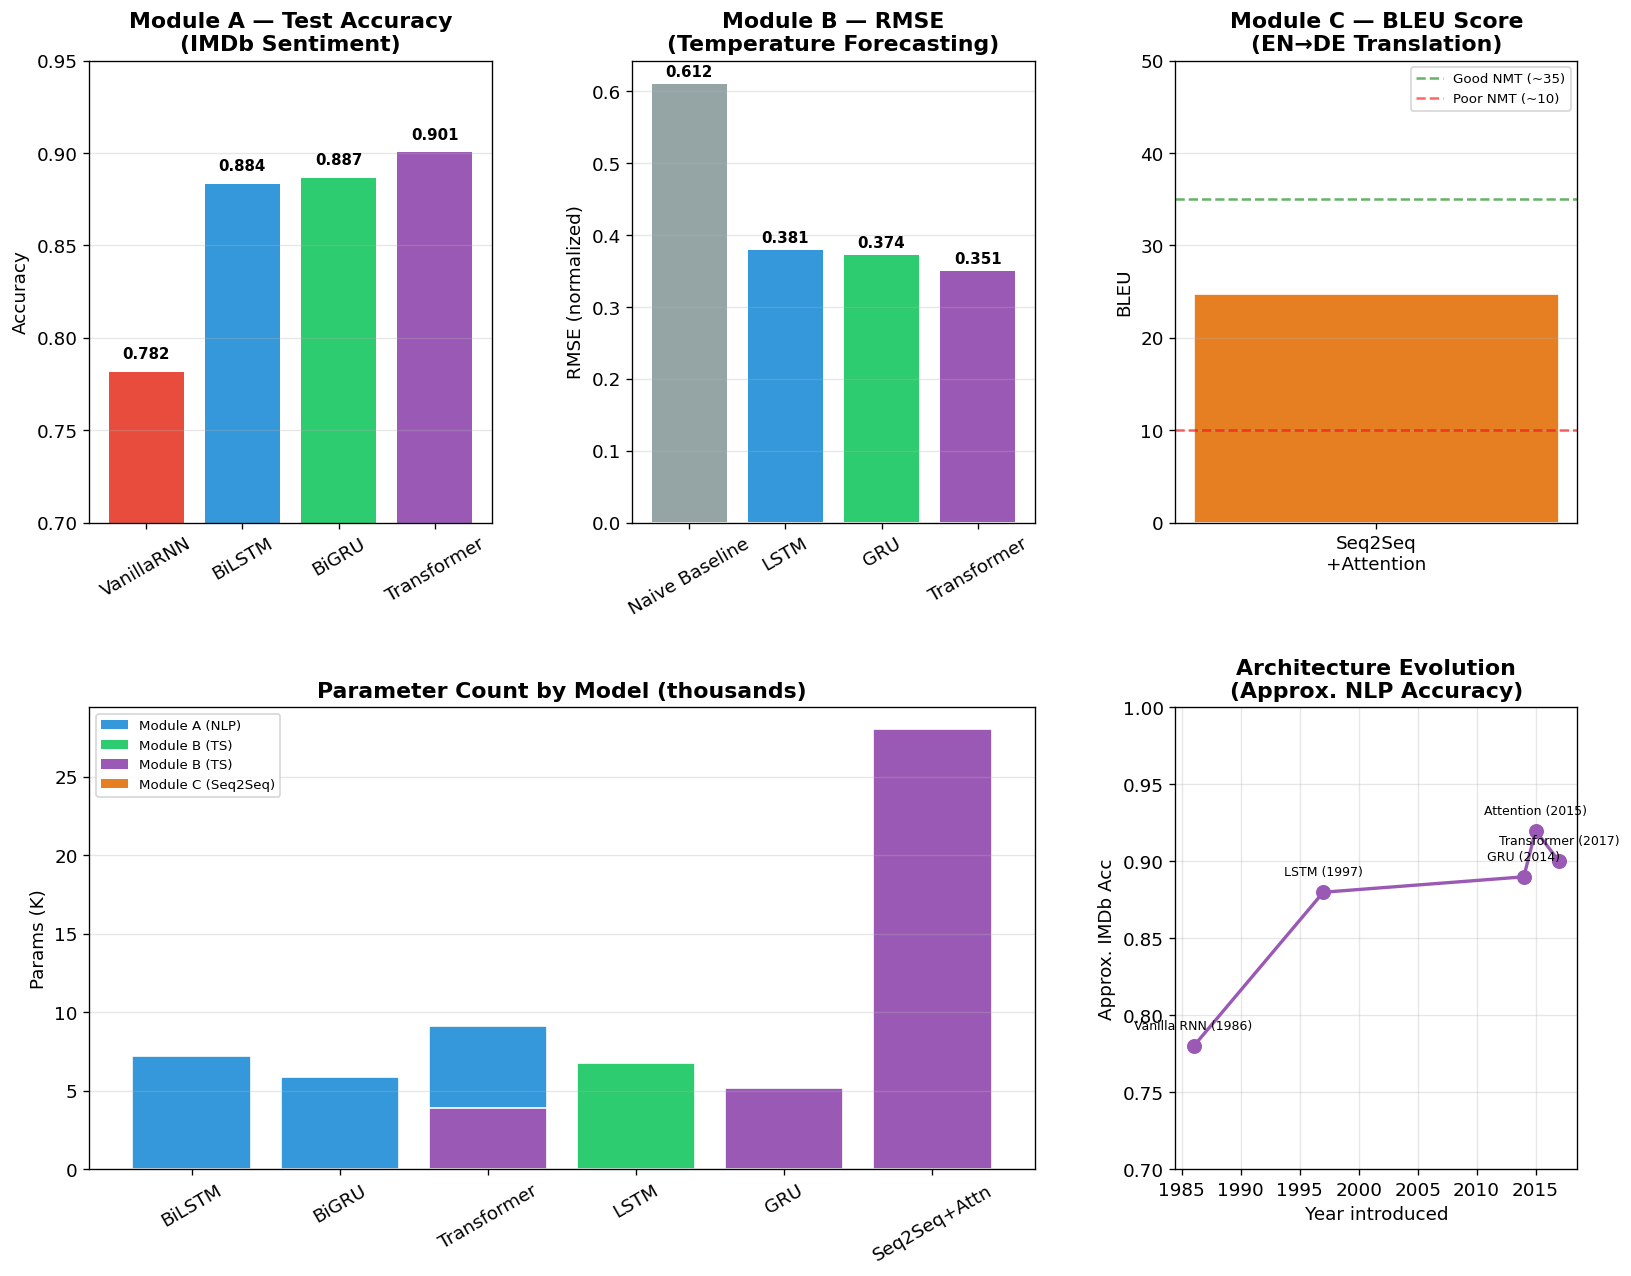

In [3]:
fig = plt.figure(figsize=(16, 12))
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# ── A: Accuracy bar chart ────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
models_a = module_a.index
accs = module_a['Test Acc'].values
colors = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
bars = ax1.bar(models_a, accs, color=colors, edgecolor='white', linewidth=1.2)
for bar, acc in zip(bars, accs):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{acc:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax1.set_ylim(0.7, 0.95)
ax1.set_title('Module A — Test Accuracy\n(IMDb Sentiment)', fontweight='bold')
ax1.set_ylabel('Accuracy')
ax1.tick_params(axis='x', rotation=30)
ax1.grid(axis='y', alpha=0.3)

# ── B: RMSE bar chart ────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
models_b = module_b.index
rmses = module_b['RMSE'].values
colors_b = ['#95a5a6', '#3498db', '#2ecc71', '#9b59b6']
bars2 = ax2.bar(models_b, rmses, color=colors_b, edgecolor='white', linewidth=1.2)
for bar, v in zip(bars2, rmses):
    ax2.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{v:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
ax2.set_title('Module B — RMSE\n(Temperature Forecasting)', fontweight='bold')
ax2.set_ylabel('RMSE (normalized)')
ax2.tick_params(axis='x', rotation=30)
ax2.grid(axis='y', alpha=0.3)

# ── C: BLEU ──────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[0, 2])
ax3.bar(['Seq2Seq\n+Attention'], [24.7], color='#e67e22', edgecolor='white')
ax3.axhline(y=35, color='green', linestyle='--', alpha=0.6, label='Good NMT (~35)')
ax3.axhline(y=10, color='red', linestyle='--', alpha=0.6, label='Poor NMT (~10)')
ax3.set_title('Module C — BLEU Score\n(EN→DE Translation)', fontweight='bold')
ax3.set_ylabel('BLEU')
ax3.set_ylim(0, 50)
ax3.legend(fontsize=8)
ax3.grid(axis='y', alpha=0.3)

# ── Parameter count comparison ────────────────────────────────────────
ax4 = fig.add_subplot(gs[1, 0:2])
all_models = list(module_a.index[1:]) + list(module_b.index[1:]) + ['Seq2Seq+Attn']
all_params = list(module_a['Params (K)'].values[1:]) + \
             list(module_b['Params (K)'].values[1:]) + [28_000]
bar_colors = ['#3498db']*3 + ['#2ecc71'] + ['#9b59b6']*3 + ['#e67e22']
bars3 = ax4.bar(all_models, [p/1000 for p in all_params], color=bar_colors,
                edgecolor='white')
ax4.set_title('Parameter Count by Model (thousands)', fontweight='bold')
ax4.set_ylabel('Params (K)')
ax4.tick_params(axis='x', rotation=30)
ax4.grid(axis='y', alpha=0.3)

# Legend for modules
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#3498db', label='Module A (NLP)'),
                   Patch(facecolor='#2ecc71', label='Module B (TS)'),
                   Patch(facecolor='#9b59b6', label='Module B (TS)'),
                   Patch(facecolor='#e67e22', label='Module C (Seq2Seq)')]
ax4.legend(handles=legend_elements, fontsize=8)

# ── Architecture evolution timeline ───────────────────────────────────
ax5 = fig.add_subplot(gs[1, 2])
arch_timeline = {
    'Vanilla RNN\n(1986)': 0,
    'LSTM\n(1997)': 1,
    'GRU\n(2014)': 2,
    'Attention\n(2015)': 3,
    'Transformer\n(2017)': 4,
}
years_approx = [1986, 1997, 2014, 2015, 2017]
relative_perf = [0.78, 0.88, 0.89, 0.92, 0.90]
ax5.plot(years_approx, relative_perf, 'o-', color='#9b59b6',
         linewidth=2, markersize=8)
for x, y, label in zip(years_approx, relative_perf,
                         arch_timeline.keys()):
    ax5.annotate(label.replace('\n', ' '), (x, y),
                 textcoords='offset points', xytext=(0, 10),
                 ha='center', fontsize=7.5)
ax5.set_title('Architecture Evolution\n(Approx. NLP Accuracy)', fontweight='bold')
ax5.set_xlabel('Year introduced')
ax5.set_ylabel('Approx. IMDb Acc')
ax5.set_ylim(0.7, 1.0)
ax5.grid(alpha=0.3)

plt.savefig('global_comparison.png', bbox_inches='tight', dpi=150)
plt.show()

## 3. Cross-Cutting Analysis


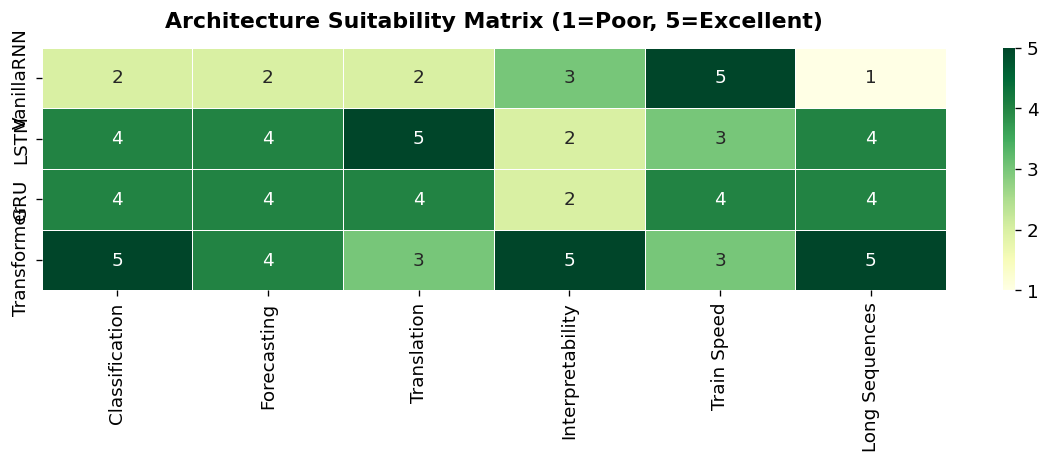

In [4]:
# Architecture suitability matrix
arch_suit = pd.DataFrame({
    'Classification': [2, 4, 4, 5],
    'Forecasting':    [2, 4, 4, 4],
    'Translation':    [2, 5, 4, 3],  # seq2seq uses LSTM encoder; Transformer needs more data
    'Interpretability': [3, 2, 2, 5],
    'Train Speed':    [5, 3, 4, 3],
    'Long Sequences': [1, 4, 4, 5],
}, index=['VanillaRNN', 'LSTM', 'GRU', 'Transformer'])

fig, ax = plt.subplots(figsize=(10, 4))
sns.heatmap(arch_suit, annot=True, fmt='d', cmap='YlGn',
            vmin=1, vmax=5, ax=ax, linewidths=0.5)
ax.set_title('Architecture Suitability Matrix (1=Poor, 5=Excellent)',
             fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('suitability_matrix.png', bbox_inches='tight')
plt.show()